# Employee Survey Data Analysis

## Import Libraries

In [8]:
import json

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "clean_survey_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

from scipy.stats import kruskal


## Load Dataset

import pandas as pd

df = pd.read_csv("../data/processed/clean_survey_data.csv")

df.head()

## Basic Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 1000 non-null   object 
 1   department                  1000 non-null   object 
 2   role                        1000 non-null   object 
 3   tenure_years                1000 non-null   float64
 4   q_work_life_balance         1000 non-null   float64
 5   q_manager_effectiveness     1000 non-null   float64
 6   q_career_growth             1000 non-null   float64
 7   overall_satisfaction        1000 non-null   float64
 8   satisfaction_category       1000 non-null   object 
 9   open_comment                1000 non-null   object 
 10  composite_engagement_score  1000 non-null   float64
dtypes: float64(6), object(5)
memory usage: 86.1+ KB


In [11]:
df.describe()

,tenure_years,q_work_life_balance,q_manager_effectiveness,q_career_growth,overall_satisfaction,composite_engagement_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,4.202300,3.059000,3.717000,3.161000,3.324000,3.31229
std,2.649454,1.091196,0.939038,1.110095,0.872803,0.61590
min,0.500000,1.000000,1.000000,1.000000,1.000000,1.33000
25%,2.100000,2.000000,3.000000,2.000000,3.000000,3.00000
50%,4.000000,3.000000,4.000000,3.000000,3.000000,3.33000
75%,6.000000,4.000000,4.000000,4.000000,4.000000,3.67000
max,13.600000,5.000000,5.000000,5.000000,5.000000,5.00000


In [12]:
df.isnull().sum()

employee_id                   0
department                    0
role                          0
tenure_years                  0
q_work_life_balance           0
q_manager_effectiveness       0
q_career_growth               0
overall_satisfaction          0
satisfaction_category         0
open_comment                  0
composite_engagement_score    0
dtype: int64

## Distribution of Satisfaction

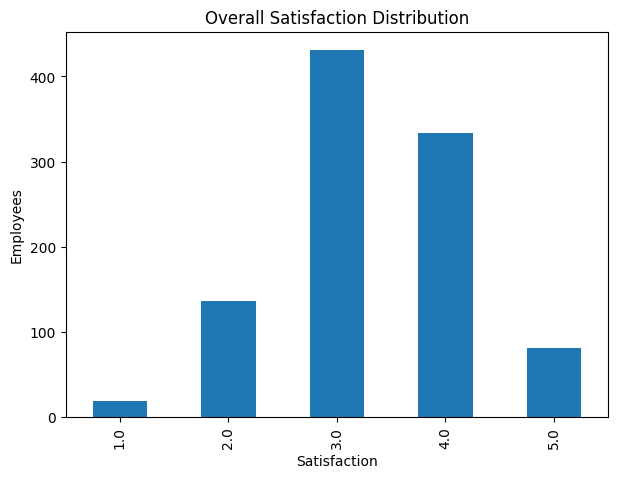

In [13]:
plt.figure(figsize=(7,5))

df["overall_satisfaction"].value_counts().sort_index().plot(kind="bar")

plt.title("Overall Satisfaction Distribution")

plt.xlabel("Satisfaction")

plt.ylabel("Employees")

plt.show()

## Satisfaction by Department

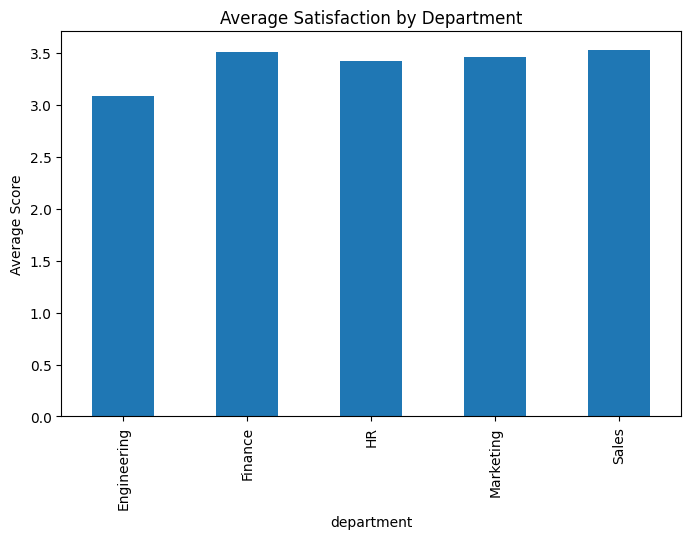

In [14]:
department_scores = df.groupby("department")["overall_satisfaction"].mean()

department_scores.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Satisfaction by Department")

plt.ylabel("Average Score")

plt.show()

## Correlation Matrix

In [15]:
correlation = df[
    [
        "q_work_life_balance",
        "q_manager_effectiveness",
        "q_career_growth",
        "overall_satisfaction",
        "composite_engagement_score"
    ]
].corr()

correlation

,q_work_life_balance,q_manager_effectiveness,q_career_growth,overall_satisfaction,composite_engagement_score
q_work_life_balance,1.000000,0.050503,0.014462,0.523291,0.624676
q_manager_effectiveness,0.050503,1.000000,-0.013863,0.447854,0.529649
q_career_growth,0.014462,-0.013863,1.000000,0.264314,0.602470
overall_satisfaction,0.523291,0.447854,0.264314,1.000000,0.695387
composite_engagement_score,0.624676,0.529649,0.602470,0.695387,1.000000


## Hypothesis Testing

Null Hypothesis (H₀):
Employee satisfaction is the same across all departments.

Alternative Hypothesis (H₁):
At least one department has a different level of employee satisfaction.

In [18]:
from scipy.stats import kruskal

groups = []

for department in sorted(df["department"].unique()):
    department_scores = df.loc[
        df["department"] == department,
        "overall_satisfaction"
    ]
    groups.append(department_scores)

statistic, p_value = kruskal(*groups)

print(f"Test Statistic : {statistic:.4f}")
print(f"P-value        : {p_value:.6f}")

if p_value < 0.05:
    print("\nConclusion: Reject the Null Hypothesis.")
    print("Employee satisfaction differs significantly across departments.")
else:
    print("\nConclusion: Fail to Reject the Null Hypothesis.")
    print("No statistically significant difference was found.")

Test Statistic : 52.1131
P-value        : 0.000000

Conclusion: Reject the Null Hypothesis.
Employee satisfaction differs significantly across departments.


In [19]:
import json
from pathlib import Path

results = {
    "test_name": "Kruskal-Wallis",
    "statistic": float(statistic),
    "p_value": float(p_value)
}

output_path = PROJECT_ROOT / "statistical_results.json"

with open(output_path, "w") as file:
    json.dump(results, file, indent=4)

print("Saved to:", output_path)

Saved to: D:\GPP Projects\SatisfyAI\statistical_results.json
